### Step 1 – Load Data

In [2]:
import os

print("Current working directory:", os.getcwd())

Current working directory: c:\Users\Babak.Baradaranhezav\ml-projects\ml_airbnb_price_regression\notebooks


In [3]:
from pathlib import Path
import os

# Set working directory only if not already set
cwd = Path.cwd()
if not (cwd / ".git").exists():
    for parent in cwd.parents:
        if (parent / ".git").exists():
            os.chdir(parent)
            print("Working directory set to repo root:", parent)
            break
    else:
        raise FileNotFoundError("Could not find .git repo root. Are you inside the correct project folder?")
else:
    print("Already in repo root:", cwd)


Working directory set to repo root: c:\Users\Babak.Baradaranhezav\ml-projects\ml_airbnb_price_regression


In [4]:
import pandas as pd

pd.set_option('future.no_silent_downcasting', True)

# Read the featured listings CSV using a path relative to the repo root
df = pd.read_csv("data/processed/featured_listings.csv")

print(f"Loaded data with shape: {df.shape}")
df.head()


Loaded data with shape: (5090, 99)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,amenity_pets,amenity_microwave,amenity_refrigerator,amenity_heating,amenity_hairdryer,amenity_iron,amenity_tv,amenity_dishwasher,amenity_washer,amenity_dryer
0,13188,https://www.airbnb.com/rooms/13188,2.025060e+13,6/25/2025,city scrape,Garden level studio in ideal loc.,Garden level studio suite with garden patio - ...,The uber hip Main street area is a short walk ...,https://a0.muscache.com/pictures/8408188/e1af6...,51466,...,0,1,1,1,1,1,0,0,1,1
1,16611,https://www.airbnb.com/rooms/16611,2.025060e+13,6/21/2025,previous scrape,"1 block to skytrain station, shops,restaurant,...","My place is close to bank, coffee shops, groce...",Next block to Commercial Drive which has many ...,https://a0.muscache.com/pictures/82101/7127b63...,58512,...,0,0,0,1,0,0,0,0,1,1
2,18270,https://www.airbnb.com/rooms/18270,2.025060e+13,6/21/2025,city scrape,private rm in clean central 2BR apt,I have a bright furnished 2 bedroom suite on a...,"Lots of restaurants, coffee shops.<br />Easy a...",https://a0.muscache.com/pictures/108520241/aec...,70437,...,0,0,1,1,1,0,0,0,1,1
3,18589,https://www.airbnb.com/rooms/18589,2.025060e+13,6/25/2025,city scrape,Commercial Drive B&B,"As hosts, we are welcoming you into our home, ...",Lots of restaurants and boutiques just outside...,https://a0.muscache.com/pictures/dd3ca406-cb74...,71508,...,0,1,1,1,1,1,0,1,1,1
4,18795,https://www.airbnb.com/rooms/18795,2.025060e+13,6/21/2025,city scrape,*Best choice in downtown-5 Stars * -2,NaN,NaN,https://a0.muscache.com/pictures/96249/03d3af8...,70137,...,0,0,1,1,1,0,0,0,1,1


Step 3 – Clean Up Target and Drop Redundant Columns

In [5]:
# Drop rows with missing price
df = df.dropna(subset=["price"])

# Drop unneeded columns
drop_cols = [
    "id", "name", "host_id", "host_name", "last_review", "license",
    "price_log"  # if accidentally retained from earlier notebooks
]
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

# Separate target
target = "price"
y = df[target]
X = df.drop(columns=[target])


Step 4 – One-Hot Encode and Align Types

In [6]:
# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Fill any residual missing values (e.g., from host_age_days or review scores)
X = X.fillna(0).infer_objects(copy=False)

# Ensure alignment
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

print("Final feature matrix shape:", X.shape)


Final feature matrix shape: (4238, 28303)


Step 5 – Train/Test Split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train rows: {len(X_train)} | Test rows: {len(X_test)}")


Train rows: 3390 | Test rows: 848


Step 6 – Baseline Model (Mean Price)


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Step 5 – Baseline Model: Predict mean price
mean_price = y_train.mean()
y_pred_baseline = [mean_price] * len(y_test)

# Evaluate
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))  # manually apply sqrt

print(f"Baseline MAE: {mae_baseline:.2f}")
print(f"Baseline RMSE: {rmse_baseline:.2f}")


Baseline MAE: 126.85
Baseline RMSE: 187.42


Step 7 – Train Linear Regression

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Evaluate
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))  # replace squared=False

print(f"Linear Regression MAE: {mae_lr:.2f}")
print(f"Linear Regression RMSE: {rmse_lr:.2f}")


Linear Regression MAE: 68.60
Linear Regression RMSE: 110.17


Step 8 – Ridge Regression

In [10]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))  # fixed here

print(f"Ridge Regression MAE: {mae_ridge:.2f}")
print(f"Ridge Regression RMSE: {rmse_ridge:.2f}")


Ridge Regression MAE: 67.94
Ridge Regression RMSE: 109.39


Step 9 – Random Forest Regressor

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Train the model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))  # manual square root

print("Random Forest Regressor")
print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")


Random Forest Regressor
MAE: 42.76
RMSE: 116.47


Step 10 - XGBOOST with Hyperparameter Tuning.

I first used XGBOOST with default hyperparameters. I got this:

Model         MAE        RMSE
XGBoost    46.777335   94.247686

Then, I used GridSearchCV to tune the hyperparameters of XG and despite takes longer (around 20 min on my current pc) got better result:
Model         MAE        RMSE
XGBoost      43.42       92.22

So I decided to keep the tuned model because despite small improvement (Closer to actual value by ~$3.36 on average), every dollar and every booking counts in pricing model.
Also I don't want to train this model every night, so the training time is not a factor but the prediction.

In [12]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Clean column names for compatibility
X_train_xgb = X_train.copy()
X_train_xgb.columns = X_train_xgb.columns.str.replace(r'[\[\]<>]', '_', regex=True)
X_test_xgb = X_test.copy()
X_test_xgb.columns = X_test_xgb.columns.str.replace(r'[\[\]<>]', '_', regex=True)

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Setup model
xgb_model = XGBRegressor(random_state=42)

# Use GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search.fit(X_train_xgb, y_train)

# Best model
best_xgb = grid_search.best_estimator_
print("Best XGBoost Parameters:", grid_search.best_params_)


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best XGBoost Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Predict using best model
y_pred_xgb = best_xgb.predict(X_test_xgb)

# Evaluate
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost Regressor (Tuned)")
print(f"MAE: {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")


XGBoost Regressor (Tuned)
MAE: 43.42
RMSE: 92.22


Step 10 – Model Comparison Summary

Model Comparison:
               Model         MAE        RMSE
0            XGBoost   43.415064   92.222716
1   Ridge Regression   67.937924  109.388136
2  Linear Regression   68.599358  110.173088
3      Random Forest   42.756675  116.473247
4    Baseline (Mean)  126.845122  187.421806


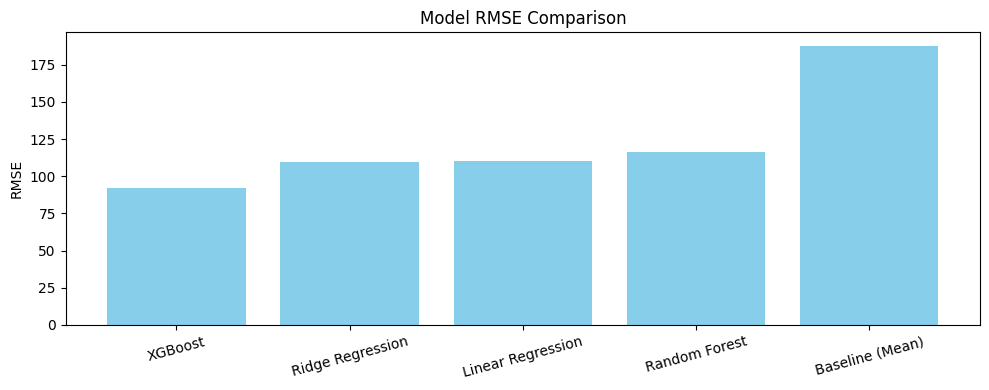

In [18]:
import matplotlib.pyplot as plt

results = pd.DataFrame({
    'Model': ['Baseline (Mean)', 'Linear Regression', 'Ridge Regression', 'Random Forest', 'XGBoost'],
    'MAE': [mae_baseline, mae_lr, mae_ridge, mae_rf, mae_xgb],
    'RMSE': [rmse_baseline, rmse_lr, rmse_ridge, rmse_rf, rmse_xgb]
})

results = results.sort_values(by='RMSE').reset_index(drop=True)
print("Model Comparison:")
print(results)

# Visualization
plt.figure(figsize=(10, 4))
plt.bar(results['Model'], results['RMSE'], color='skyblue')
plt.title("Model RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


Step 11 – Save Train/Test Data Split

In [19]:
# Save train and test sets
X_train[target] = y_train
X_test[target] = y_test

X_train.to_csv("data/processed/featured_listings.csv", index=False)
X_test.to_csv("data/processed/test.csv", index=False)

print("Train/test data saved.")


Train/test data saved.


In [22]:
import pandas as pd
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

# Load featured data
df_raw = pd.read_csv("data/processed/featured_listings.csv")

# Get feature columns (excluding target)
target = "price"
feature_columns = [col for col in df_raw.columns if col != target]

# Identity transformer to pass through preprocessed data
identity_transformer = ColumnTransformer([
    ('identity', FunctionTransformer(validate=False), feature_columns)
])

pipeline = Pipeline(steps=[('preprocessor', identity_transformer)])

# Fit pipeline to final dataset
pipeline.fit(df_raw[feature_columns])

# Save pipeline
joblib.dump(pipeline, "models/fitted_pipeline.joblib")
print("Fitted identity pipeline saved to models/fitted_pipeline.joblib")


Fitted identity pipeline saved to models/fitted_pipeline.joblib


Step 12 – Save XGBOOST Tuned Model and Columns with proper naming

In [23]:
import joblib
from pathlib import Path

models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

# Save the best XGBoost model
joblib.dump(best_xgb, models_dir / "xgboost_model_v1_tuned.joblib")

# Save the cleaned column names
joblib.dump(X_train_xgb.columns.tolist(), models_dir / "model_columns_v1_tuned.joblib")

print("XGBoost tuned model and columns saved.")


XGBoost tuned model and columns saved.


### Splitting to the train and test set

from sklearn.model_selection import train_test_split
import pandas as pd

# Load featured listings
df = pd.read_csv("data/processed/featured_listings.csv")

# Split into train/test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Save training data back to featured_listings.csv
train_df.to_csv("data/processed/featured_listings.csv", index=False)

# Save test data separately
test_df.to_csv("data/processed/test.csv", index=False)

print("Split into train and test sets.")
print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")


### Step 10 - Created a train_model.py at route of the project. Now I need to run that file to train the model.
#### run the file using this code: python train_model.py in ml_airbnb_price_regression directory.

### Step 11 - Trained model evaluation

In [81]:
import pandas as pd
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from math import sqrt


# Load test data
df_test = pd.read_csv("data/processed/test.csv")

# Drop rows with missing target (price)
df_test = df_test.dropna(subset=["price"])

# Define features
numerical_features = ['accommodates', 'bathrooms', 'bedrooms', 'beds',
                      'minimum_nights', 'maximum_nights',
                      'number_of_reviews', 'review_scores_rating']

categorical_features = ['host_is_superhost', 'instant_bookable', 'neighbourhood_cleansed', 'room_type']

# Prepare test features
X_test = df_test[numerical_features + categorical_features].copy()
y_test = df_test["price"]

# Ensure categorical fields are string
for col in categorical_features:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype(str)

# Load pipeline and model
pipeline = joblib.load("models/fitted_pipeline.joblib")
model = joblib.load("models/random_forest_model.joblib")

# Preprocess
X_test_processed = pipeline.transform(X_test)

# Predict
y_pred = model.predict(X_test_processed)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = sqrt(mean_squared_error(y_test, y_pred))  # No `squared` param
r2 = r2_score(y_test, y_pred)

print("Model Evaluation on Test Set:")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")


Model Evaluation on Test Set:
MAE : 96.85
RMSE: 268.14
R²  : -0.4529


### Step 11 - Created predict.py in src folder for price prediction

### Step 12 - Prediction on the data
##### Now that we have our model, we can use it to make predictions on the data.
##### On terminal or VSCODE pwsh , run the following command: python src/predict.py sample_listing.json

In [75]:
# Testing toi see whe the predict.py is locatedport os
print("Notebook Path:", Path().resolve())
print("src exists:", (Path().resolve().parents[0] / "src").exists())
print("predict.py exists:", (Path().resolve().parents[0] / "src" / "predict.py").exists())


Notebook Path: C:\Users\Babak.Baradaranhezav\ml-projects\ml_airbnb_price_regression
src exists: False
predict.py exists: False


In [57]:
import inspect
import src.predict

print(dir(src.predict))  # Lists everything defined in the module


['Path', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'build_preprocessing_pipeline', 'categorical_features', 'datetime', 'joblib', 'log_dir', 'logging', 'model', 'model_columns', 'np', 'numerical_features', 'pd', 'pipeline', 'predict_price_advanced_module', 'project_root', 'sys', 'uuid']


### So now that we completed our modeling and also trained our model using train_model.py, and because I created a predict.py in src folder, we can now use our model to make predictions. Let's see how we can do that.
##### We can predict the price if we complete a sample_listing.json file located in the route of the project.
##### We can predict using two different ways:
##### 1 - Terminal: python src/predict.py sample_listing.json
##### 2 - Jupyter Notebook: see the below code cell (the json file is already loaded in the cell).

In [ ]:
import sys
import importlib
from pathlib import Path

# Ensure src is in path
project_root = Path().resolve()
src_path = str(project_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Force reload
import src.predict
importlib.reload(src.predict)

from src.predict import predict_price



sample_input = {
  "accommodates": 2,
  "bathrooms": 1.0,
  "bedrooms": 1.0,
  "beds": 1.0,
  "minimum_nights": 2,
  "maximum_nights": 1125,
  "number_of_reviews": 35,
  "review_scores_rating": 92.0,
  "host_is_superhost": "t",
  "instant_bookable": "t",
  "neighbourhood_cleansed": "Downtown",
  "room_type": "Entire home/apt",
  "Has_Wifi": 1,
  "Has_Kitchen": 1,
  "Has_Heating": 1,
  "Has_TV": 1,
  "Has_Essentials": 1,
  "Has_Hair_Dryer": 0,
  "Has_Iron": 1,
  "Has_Free_Parking": 0,
  "Has_Hangers": 1,
  "Has_Laptop_Friendly_Workspace": 1
}


predict_price(sample_input)


ValueError: columns are missing: {'host_thumbnail_url_https://a0.muscache.com/im/pictures/user/User-122460823/original/e9be3eae-6754-4e88-80ee-a093ade83838.jpeg?aki_policy=profile_small', 'first_review_2/18/2022', 'host_picture_url_https://a0.muscache.com/im/pictures/user/User-571339985/original/3e724457-a5d3-454a-887d-a96e6a8b3ef7.jpeg?aki_policy=profile_x_medium', 'picture_url_https://a0.muscache.com/pictures/4a047fdb-2f13-4c23-90b4-37886fbeec96.jpg', 'host_thumbnail_url_https://a0.muscache.com/im/users/19658238/profile_pic/1407469707/original.jpg?aki_policy=profile_small', 'host_picture_url_https://a0.muscache.com/im/pictures/user/603593c7-57c9-48f4-8a74-01afe6615cae.jpg?aki_policy=profile_x_medium', 'first_review_5/16/2020', 'host_thumbnail_url_https://a0.muscache.com/im/pictures/user/54a22e08-974c-4e3f-9400-0919819dcd1f.jpg?aki_policy=profile_small', 'picture_url_https://a0.muscache.com/pictures/5224a5e4-8782-4b35-8830-6aa1e1c53b25.jpg', 'host_url_https://www.airbnb.com/users/show